# Some preliminary analysis plotting

In [1]:
from otter import Otter
import otter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

from astropy import units as u
from astropy.cosmology import Planck18 as cosmo

from scipy.stats import kstest

db = Otter('ecle-otter')

In [2]:
# read in the metadata so we know what to query for
meta = pd.read_csv('ecle-meta-data.csv')

phot = db.get_phot(names=meta.name, flux_unit='mJy', freq_unit='GHz', return_type='pandas')

/home/nfranz/astro-otter/otter/src/otter/io/transient.py:515: UserWarning: Unable to apply the source mapping because '2020MNRAS.499..482N,2021ApJ...908....4V'
  warnings.warn(f"Unable to apply the source mapping because {exc}")


In [3]:
phot

,name,converted_flux,converted_flux_err,converted_date,converted_wave,converted_freq,converted_flux_unit,converted_date_unit,converted_wave_unit,converted_freq_unit,obs_type,upperlimit,reference,telescope
0,AT2021dms,0.528195,0.000000,58611.85437,9.993082e+07,3.000,mJy,MJD,nm,GHz,radio,True,VLASS 1.2,VLA
1,AT2021dms,0.576343,0.133380,59611.08918,9.993082e+07,3.000,mJy,MJD,nm,GHz,radio,False,VLASS 2.2,VLA
12,SDSSJ0748,0.420179,0.000000,58619.75666,9.993082e+07,3.000,mJy,MJD,nm,GHz,radio,True,VLASS 1.2,VLA
13,SDSSJ0748,0.318597,0.000000,59542.41444,9.993082e+07,3.000,mJy,MJD,nm,GHz,radio,True,VLASS 2.2,VLA
2,SDSSJ0748,0.130300,0.013500,57458.91620,5.997049e+07,4.999,mJy,MJD,nm,GHz,radio,False,15B-247,VLA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2,AT2022fpx,0.539778,0.000000,59064.12678,9.993082e+07,3.000,mJy,MJD,nm,GHz,radio,True,VLASS 2.1,VLA
3,AT2022fpx,0.340286,0.000000,59984.55133,9.993082e+07,3.000,mJy,MJD,nm,GHz,radio,True,VLASS 3.1,VLA
0,AT2017gge,0.335485,0.000000,58081.74411,9.993082e+07,3.000,mJy,MJD,nm,GHz,radio,True,VLASS 1.1,VLA
1,AT2017gge,0.446542,0.142623,59096.07597,9.993082e+07,3.000,mJy,MJD,nm,GHz,radio,False,VLASS 2.1,VLA


/home/nfranz/astro-otter/otter/src/otter/io/transient.py:515: UserWarning: Unable to apply the source mapping because Cannot set a DataFrame with multiple columns to the single column human_readable_refs
  warnings.warn(f"Unable to apply the source mapping because {exc}")
/home/nfranz/astro-otter/otter/src/otter/io/transient.py:515: UserWarning: Unable to apply the source mapping because '2020MNRAS.499..482N,2021ApJ...908....4V'
  warnings.warn(f"Unable to apply the source mapping because {exc}")


Text(0.5, 0, 'MJD')

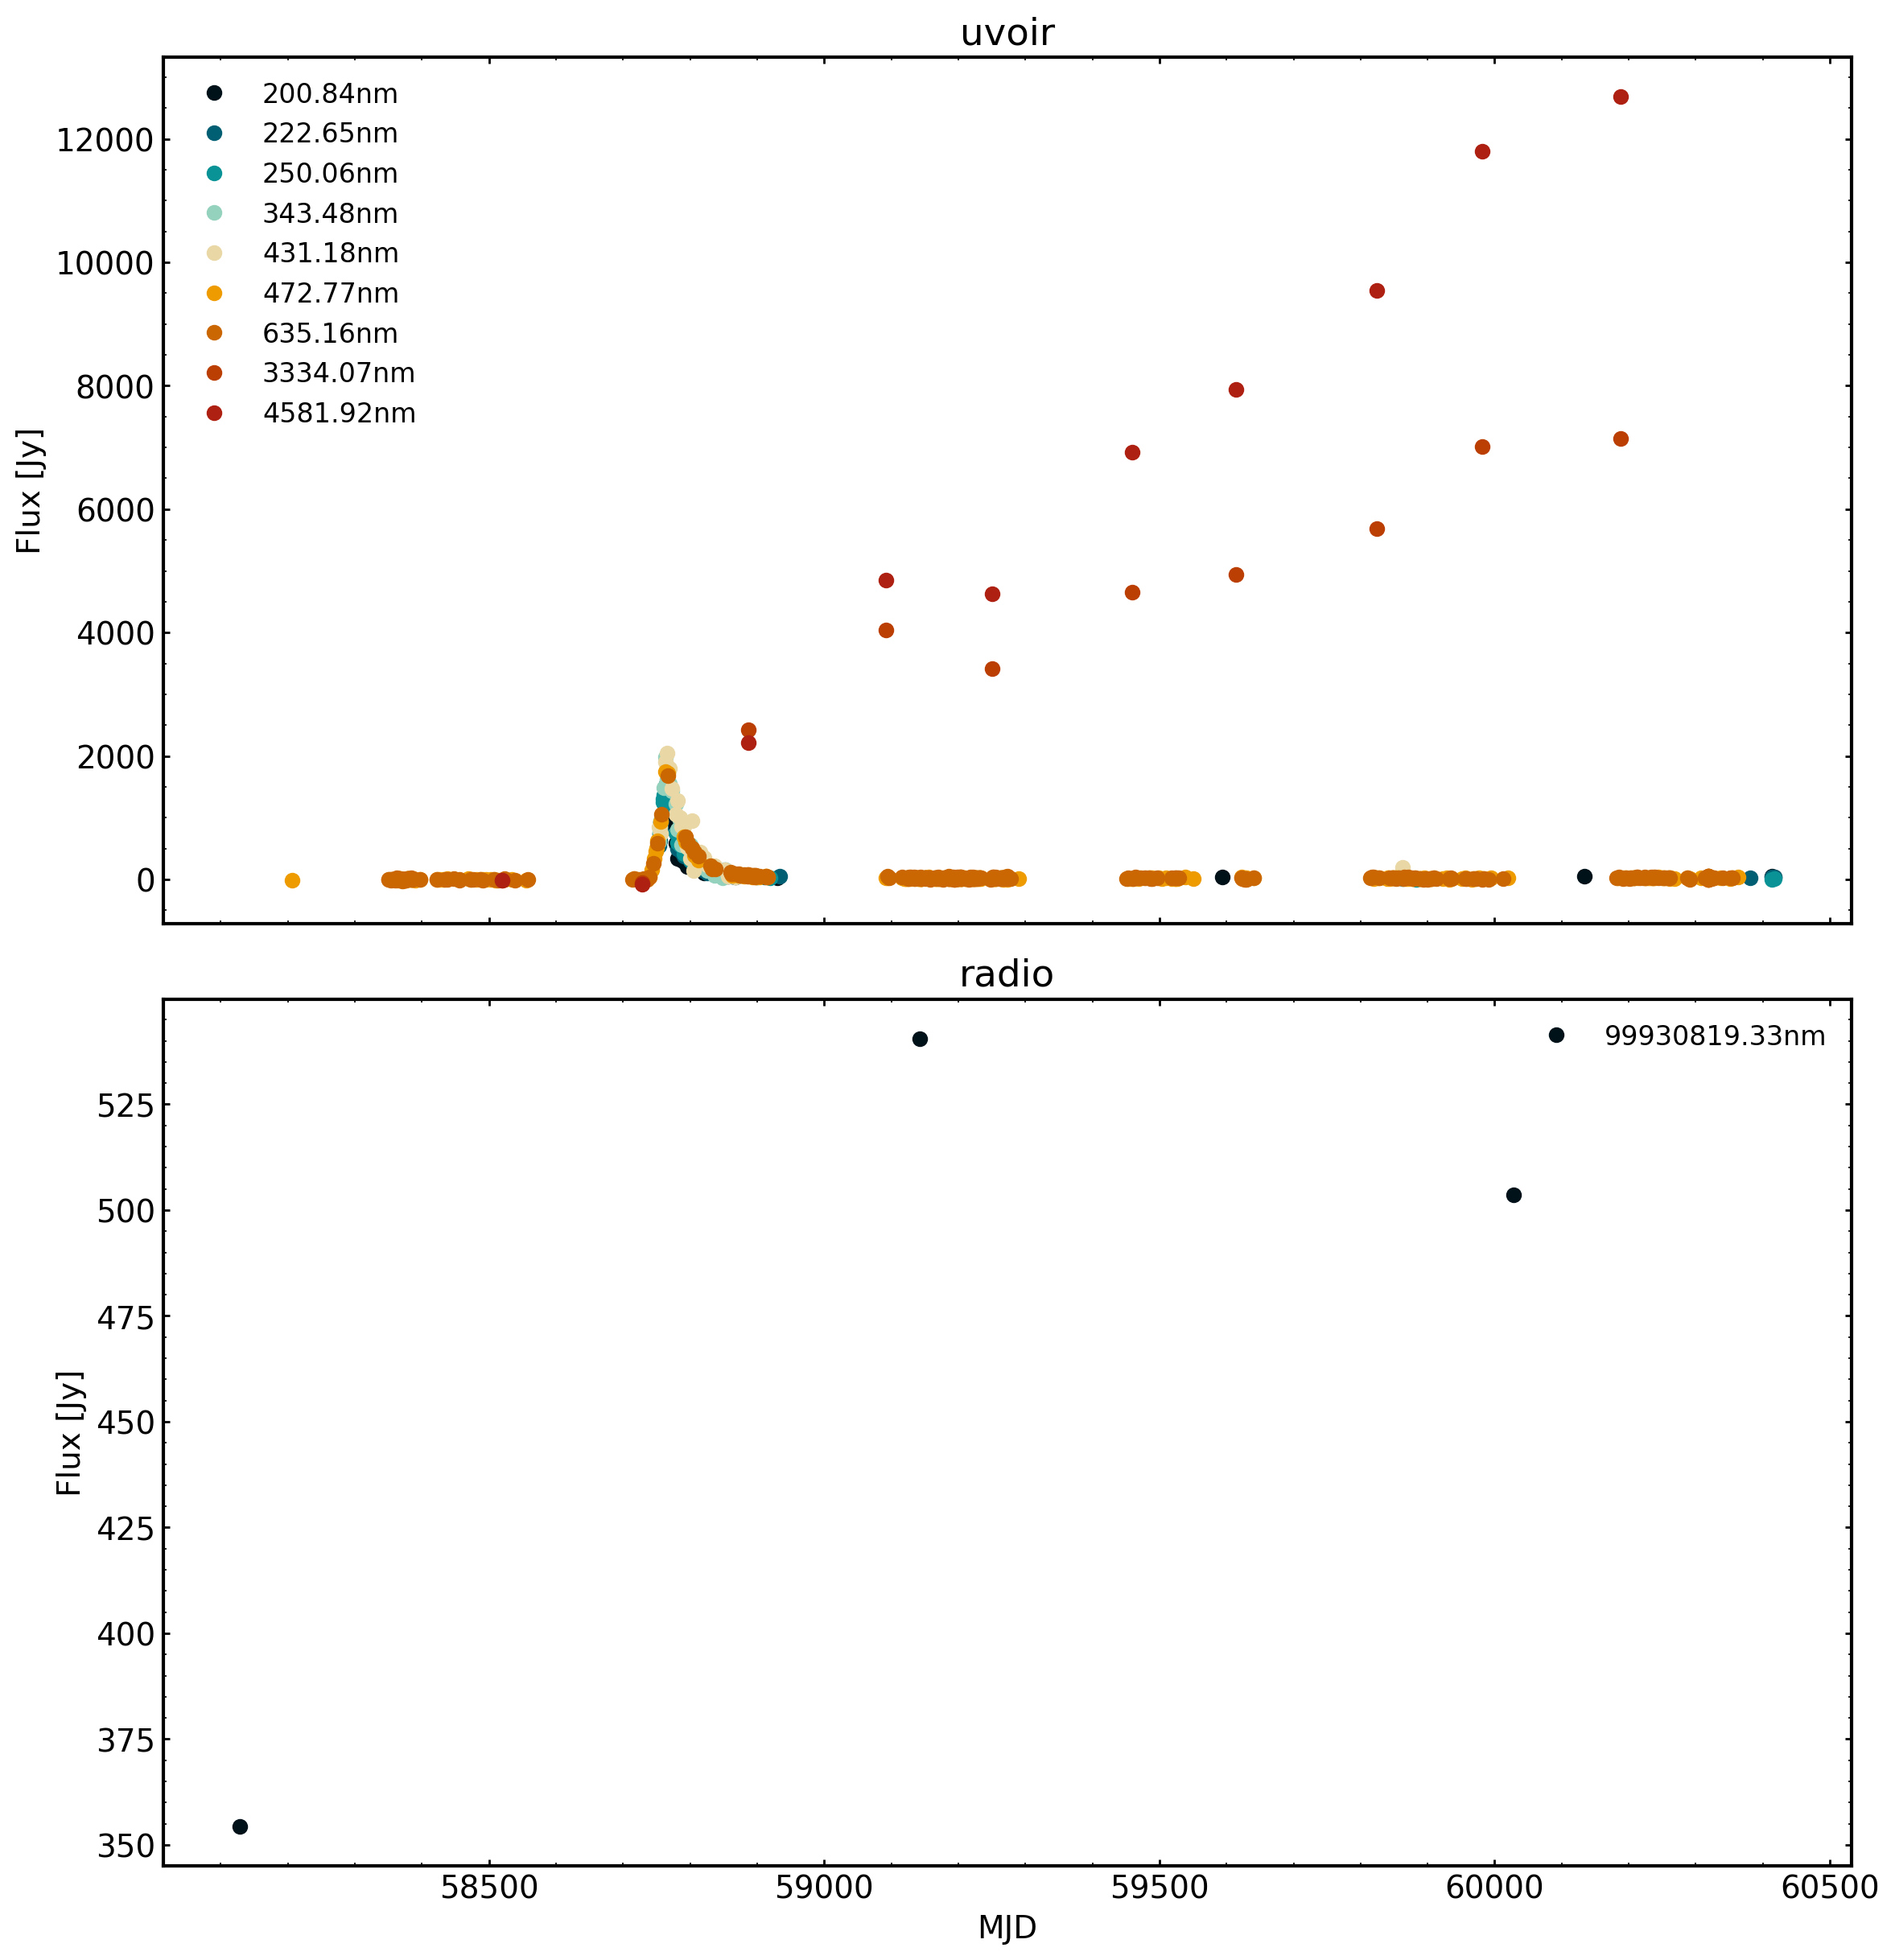

In [4]:
tde_name = '2019qiz'

fig, ax = plt.subplots(3,1, sharex=True, figsize=(12,18))

for ii, obs_type in enumerate(['xray','uvoir','radio']):
    
    try:
        df = db.get_phot(names=tde_name, return_type='pandas', 
                     flux_unit='uJy', obs_type=obs_type)
    except otter.exceptions.FailedQueryError:
        fig.delaxes(ax[ii])
        continue
    
    for label, grp in df.groupby('converted_wave'):

        # if not pd.isna(grp.converted_flux_err.iloc[0]):
        #     ax[ii].errorbar(
        #         grp.converted_date, 
        #         grp.converted_flux, 
        #         yerr=grp.converted_flux_err, 
        #         label=f'{label:.2f}nm',
        #         linestyle='none'
        #     )
        # else:
        ax[ii].plot(
            grp.converted_date, 
            grp.converted_flux,
            label=f'{label:.2f}nm',
            marker='o',
            linestyle='none'
        )

    ax[ii].set_title(obs_type)
    
    ax[ii].set_ylabel('Flux [Jy]')
    
    ax[ii].legend(fontsize=12)

ax[-1].set_xlabel('MJD')

# Let's just plot some radio light curves of all of these

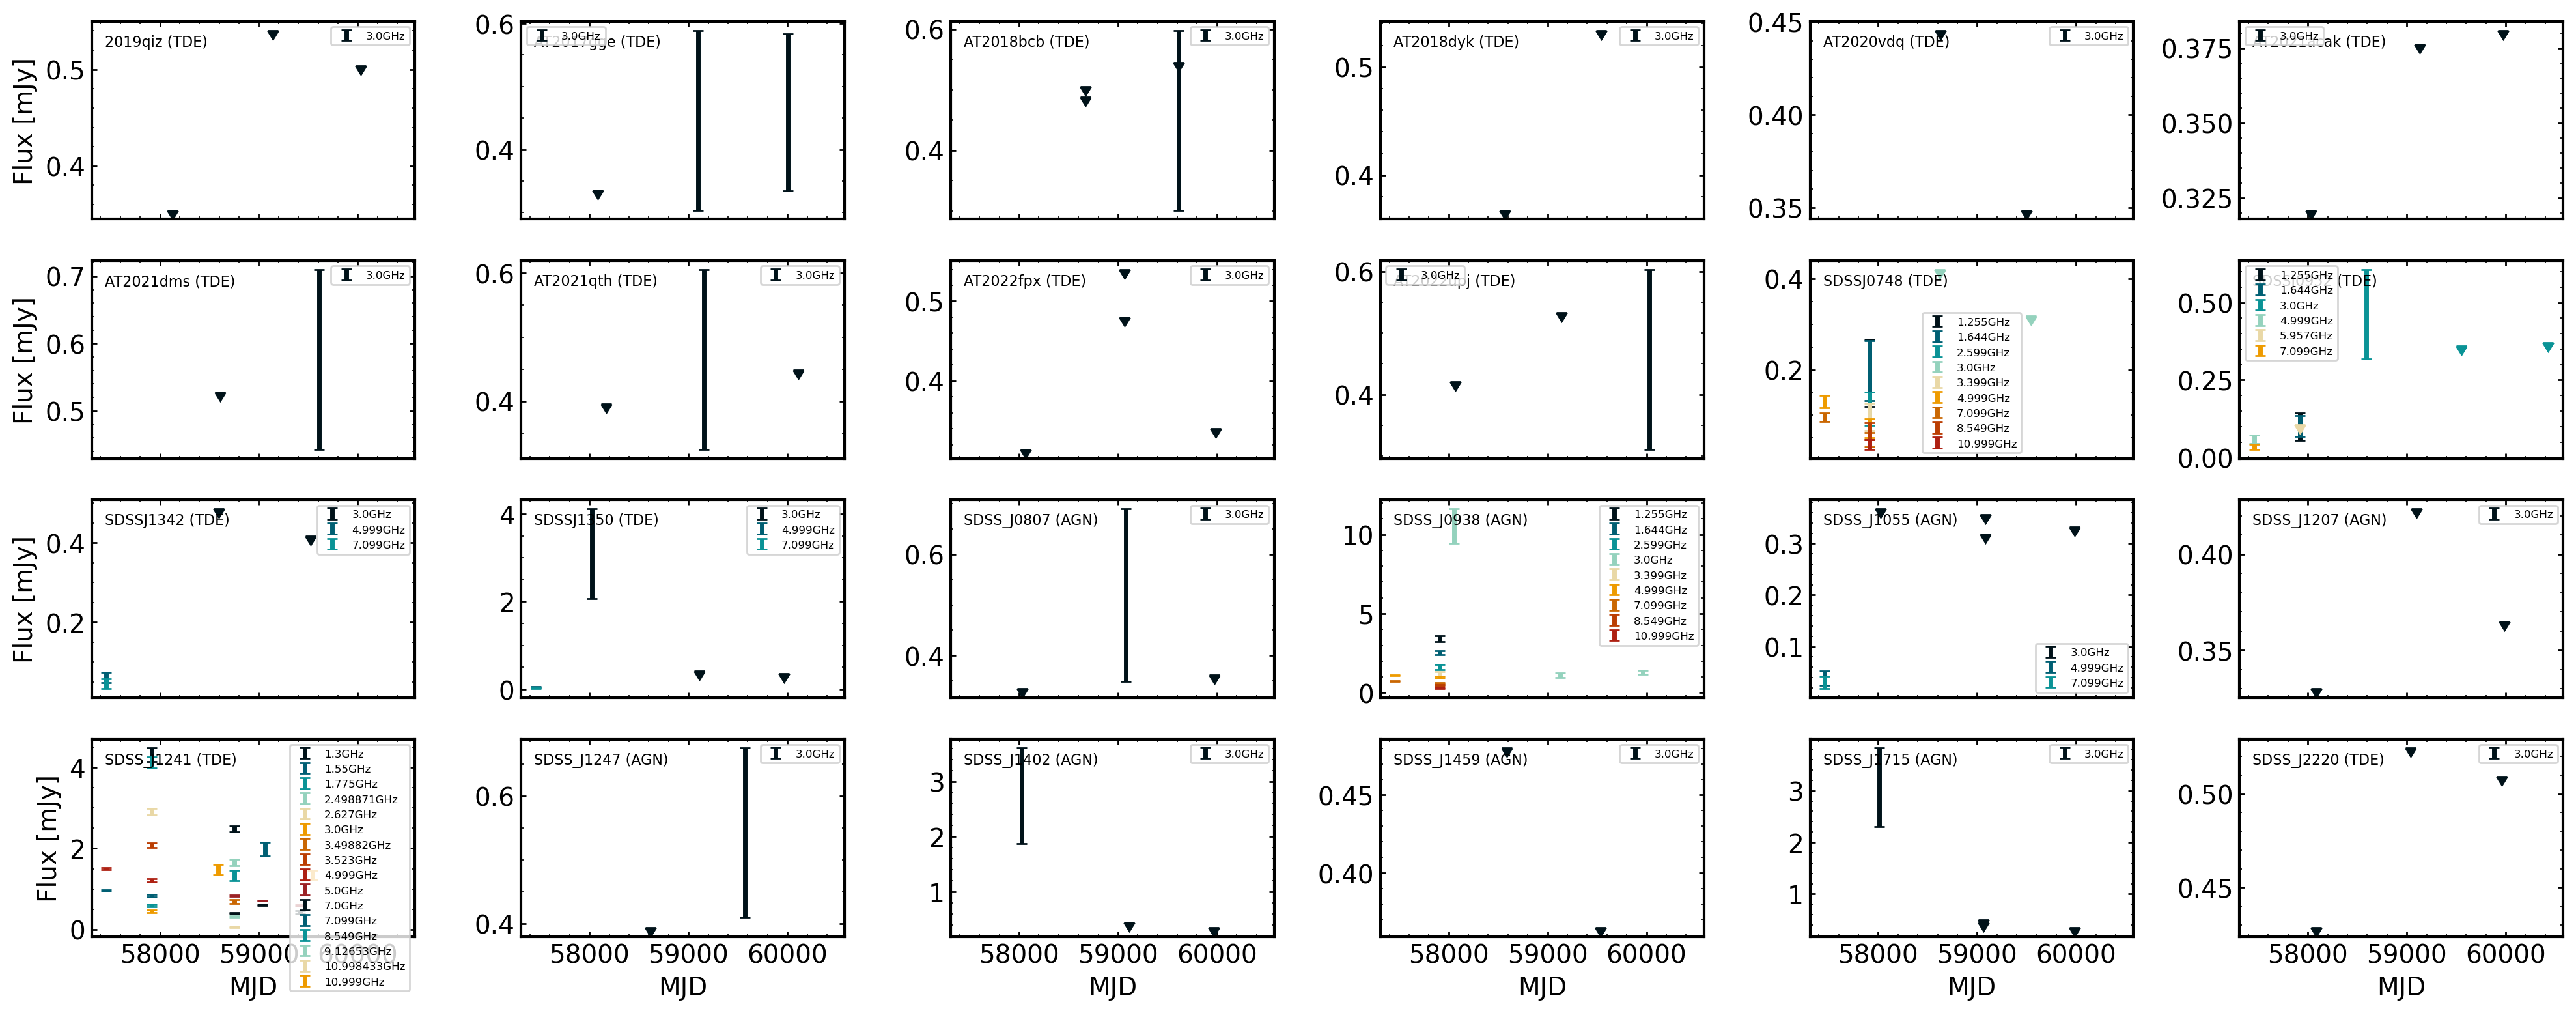

In [5]:
radio = phot[phot.obs_type == 'radio']

fig, axs2d = plt.subplots(4,6, figsize=(20,8), sharex=True)

flat_axs = axs2d.flatten() 

for idx, ((name, data), ax) in enumerate(zip(radio.groupby('name'), flat_axs)):
    
    for label, grp in data.groupby('converted_freq'):
        ax.errorbar(
            grp.converted_date,
            grp.converted_flux, 
            yerr=grp.converted_flux_err,
            label=f'{label}GHz',
            linestyle='none',
            # marker='o',
            uplims=grp.upperlimit
        )
    
    if not idx%6:
        ax.set_ylabel('Flux [mJy]')
    
    if idx >= 18:
        ax.set_xlabel('MJD')
        
    #ax.text(ax.get_xlim()[0], ax.get_ylim()[1]-ax.get_ylim()[1]//2, name)
    
    classes = db.query(names=name)[0]['classification']
    for c in classes:
        if c['object_class'] in {'AGN', 'TDE'}:
            break
    ecle_class = c['object_class']
        
    at = AnchoredText(f'{name} ({ecle_class})', 'upper left', frameon=False, prop=dict(fontsize=8))
    ax.add_artist(at)
    
    ax.legend(fontsize=6, frameon=True, fancybox=True)
    # ax.set_xscale('log')


# Look at some of the SEDs

In [6]:
def make_sed(tde_name, ax):
    classes = db.query(names=tde_name)[0]['classification']
    for c in classes:
        if c['object_class'] in {'AGN', 'TDE'}:
            break
    ecle_class = c['object_class']

    df = radio[radio.name == tde_name]

    for label, grp in df.groupby('converted_date'):

        ax.errorbar(
            grp.converted_freq, 
            grp.converted_flux,
            fmt='o',
            markersize=3,
            yerr=grp.converted_flux_err,
            label=f'{label:.2f} MJD',
            uplims=grp.upperlimit
        )

        next(ax._get_lines.prop_cycler)['color']


    ax.set_ylabel('Flux [Jy]')
    ax.set_xlabel('Frequency [GHz]')

    at = AnchoredText(f'{tde_name} ({ecle_class})', 'center right', frameon=False)
    ax.add_artist(at)

    ax.legend(fontsize=12)

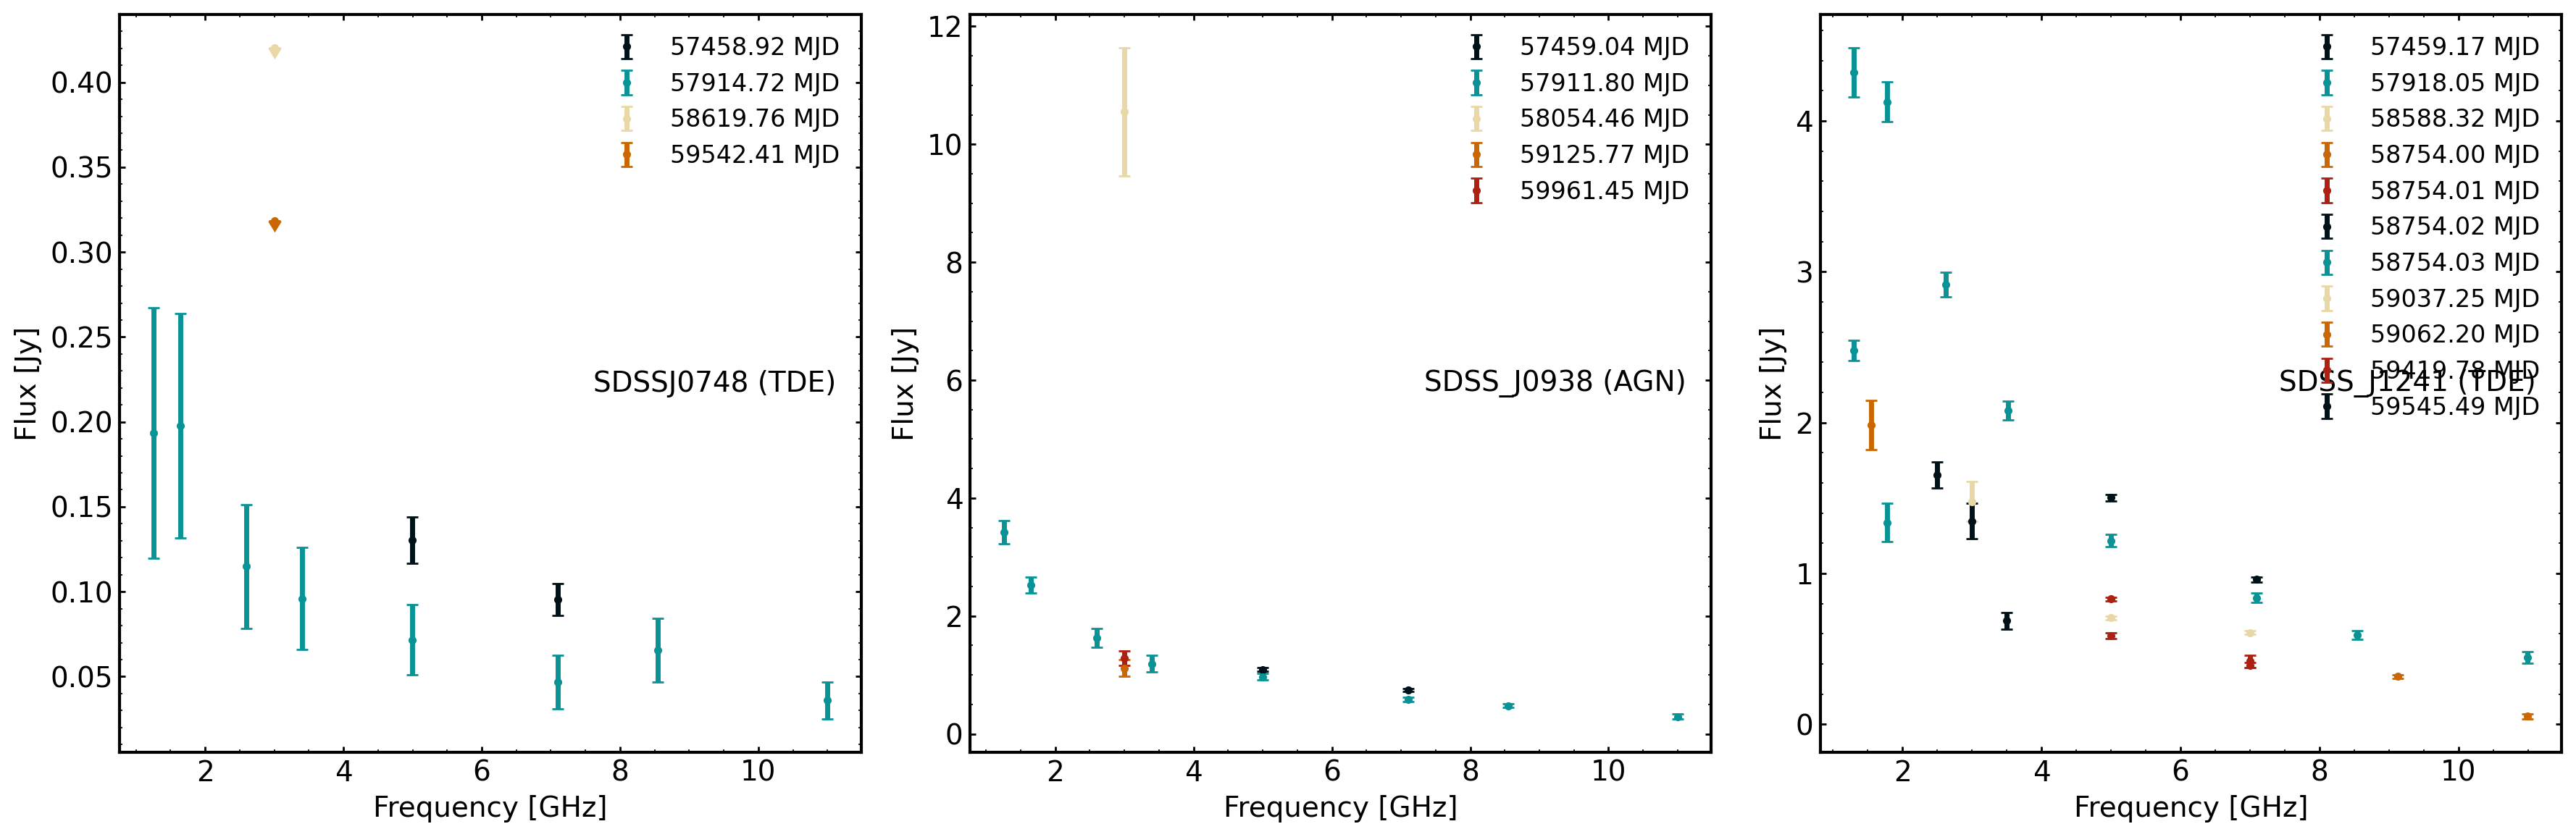

In [7]:
ecles_with_good_seds = ['SDSSJ0748','SDSS_J0938','SDSS_J1241']
fig, axs = plt.subplots(1,len(ecles_with_good_seds), figsize=(18,6))
                        
for ii, tde_name in enumerate(ecles_with_good_seds):
    make_sed(tde_name, axs[ii])

# Plot the WISE Light Curves

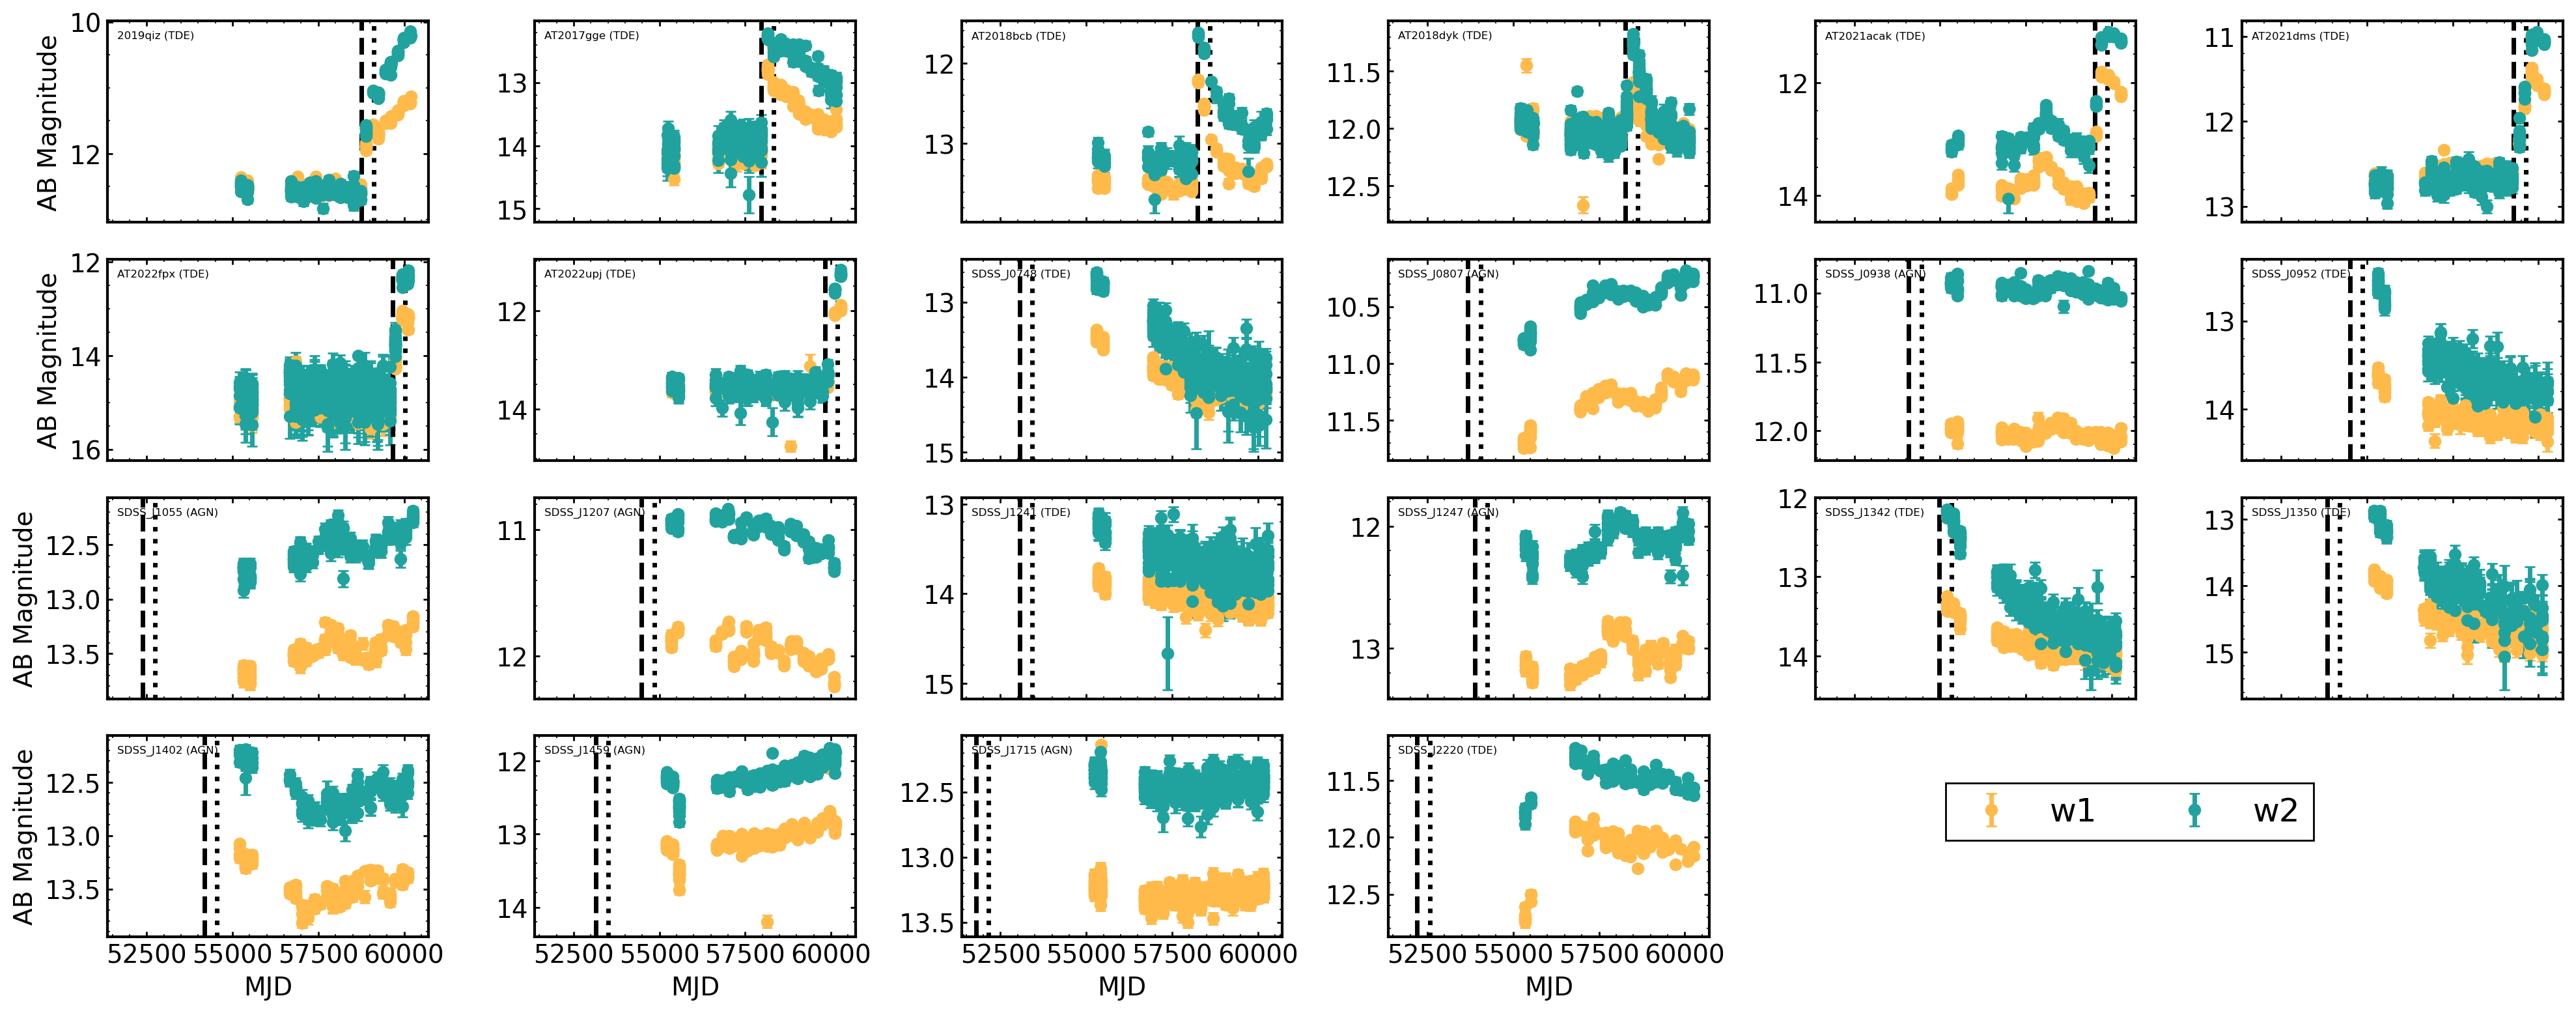

In [8]:
wise = pd.read_csv('data/wise-photometry.csv')

color_map = {'w1':'#ffba49',
             'w2': '#20a39e',
             'w3': '#ef5b5b',
             'w4': 'k'}

filters_to_plot = {'w1', 'w2'}

fig, axs2d = plt.subplots(4,6, figsize=(20,8), sharex=True)

flat_axs = axs2d.flatten() 

for idx, ((name, data), ax) in enumerate(zip(wise.groupby('name'), flat_axs)):

    for f,d in data.groupby('filter'):
        if f not in filters_to_plot: continue
        if idx == 0: 
            label = f
        else:
            label = None
        ax.errorbar(
            d.date_mjd, 
            d.flux, 
            yerr=d.flux_err, 
            color=color_map[f], 
            marker='o', 
            linestyle='none', 
            label=label
        )
        
    ax.invert_yaxis()

    if not idx%6:
        ax.set_ylabel('AB Magnitude')
    
    if idx >= 18:
        ax.set_xlabel('MJD')
        
    classes = db.query(names=name)[0]['classification']
    for c in classes:
        if c['object_class'] in {'AGN', 'TDE'}:
            break
    ecle_class = c['object_class']
    
    try:
        discovery_date = db.get_meta(names=name)[0].get_discovery_date()
        ax.axvline(discovery_date.mjd, linestyle='--', color='k')        
        ax.axvline(discovery_date.mjd+365, linestyle=':', color='k')        
    except: pass # this is fine it just means we don't have a discovery date
    
    at = AnchoredText(f'{name} ({ecle_class})', 'upper left', frameon=False, prop=dict(fontsize=6))
    ax.add_artist(at)
    
for ax in flat_axs[idx+1:]:
    ax.remove()
    
fig.legend(fontsize=18, bbox_to_anchor=(0.9,0.25), ncol=2, frameon=True, edgecolor='k', framealpha=1, fancybox=False);

# Some statistical tests with the WISE data

In [9]:
# compute the "dust echo flux"

bands = {
    'w1':3.4*u.um,
    'w2':4.6*u.um,
    'w3':12*u.um,
    'w4':22*u.um
} # in um

def flux_to_luminosity(flux, lum_dist):
    return (4*np.pi*lum_dist**2 * flux).to(u.erg/u.s)

def flux_to_abs_mag(flux, lum_dist, band):
    '''
    Convert the flux to the absolute magnitude
    '''
    lum0 = {
        'w1': flux_to_luminosity(
            (3631.00*u.Jy).to(
                u.erg/u.s/u.cm**2, 
                equivalencies=u.spectral_density(bands[band])
            ), 
            lum_dist
        ),
        'w2': flux_to_luminosity(
            (3631.00*u.Jy).to(
                u.erg/u.s/u.cm**2, 
                equivalencies=u.spectral_density(bands[band])
            ),
            lum_dist
        )
    }
    
    lum = flux_to_luminosity(flux, lum_dist)
    absmag = -2.5*np.log10(lum/lum0[band])
    
    return absmag

dust_echo_time = 365 # days

dust_echo_data = {
    'name' : [],
    'w1_flux' : [],
    'w1_lum' : [],
    'w2_flux' : [],
    'w2_lum' : [],
    'class' : [],
    'discovery_date' : []
}

for name, data in wise.groupby('name'):
    
    # some cosmological calculations
    z = meta[meta.name==name].redshift # redshift
    lum_dist = cosmo.luminosity_distance(z.values[0]) # the luminosity distance from the redshift
    
    dust_echo_data['name'].append(name)
    
    classes = db.query(names=name)[0]['classification']
    for c in classes:
        if c['object_class'] in {'AGN', 'TDE'}:
            break
    ecle_class = c['object_class']
    dust_echo_data['class'].append(ecle_class)
    
    disc_date = db.get_meta(names=name)[0].get_discovery_date().mjd
    dust_echo_data['discovery_date'].append(disc_date)

    echo_data = data[(data.date_mjd > disc_date) * (data.date_mjd < disc_date+dust_echo_time)]
    
    # first W1
    mean_mag_w1 = np.max(echo_data[echo_data['filter']=='w1'].flux, axis=0) * u.Unit('mag(AB)')
    if pd.isna(mean_mag_w1):
        # first soften the time constraints
        echo_data = data[(data.date_mjd > disc_date)]
        
        # then we just take the first point in the dataset
        mean_mag_w1 = echo_data[echo_data['filter']=='w1'].flux.values[0] * u.Unit('mag(AB)')
        
    mean_flux_w1 = mean_mag_w1.to(u.erg/u.s/u.cm**2, equivalencies=u.spectral_density(bands['w1']))
    mean_lum_w1 = flux_to_abs_mag(mean_flux_w1, lum_dist, 'w1')
    dust_echo_data['w1_flux'].append(mean_flux_w1.value)
    dust_echo_data['w1_lum'].append(mean_lum_w1.value)
    
    # then W2
    mean_mag_w2 = np.max(echo_data[echo_data['filter']=='w2'].flux, axis=0) * u.Unit('mag(AB)')
    mean_flux_w2 = mean_mag_w2.to(u.erg/u.s/u.cm**2, equivalencies=u.spectral_density(bands['w2']))
    mean_lum_w2 = flux_to_abs_mag(mean_flux_w2, lum_dist, 'w2')
    dust_echo_data['w2_flux'].append(mean_flux_w2.value)
    dust_echo_data['w2_lum'].append(mean_lum_w2.value)
    
dust_echo_df = pd.DataFrame(dust_echo_data)

dust_echo_df

,name,w1_flux,w1_lum,w2_flux,w2_lum,class,discovery_date
0,2019qiz,5.322820e-11,11.948066,4.769390e-11,11.739066,TDE,58750.410000
1,AT2017gge,7.293597e-12,14.106066,7.165770e-12,13.797066,TDE,57968.349988
2,AT2018bcb,2.974006e-11,12.580066,4.184686e-11,11.881066,TDE,58235.120000
3,AT2018dyk,5.372072e-11,11.938066,3.837628e-11,11.975066,TDE,58269.310000
4,AT2021acak,2.128834e-11,12.943066,2.547199e-11,12.420066,TDE,59509.620000
5,AT2021dms,3.909685e-11,12.283066,2.842254e-11,12.301066,TDE,59266.145706
6,AT2022fpx,6.185030e-12,14.285066,5.829924e-12,14.021066,TDE,59669.519810
7,AT2022upj,1.194928e-11,13.570066,9.873312e-12,13.449066,TDE,59822.378000
8,SDSS_J0748,1.363144e-11,13.427066,3.197885e-12,14.673066,TDE,53055.000000
9,SDSS_J0807,6.590855e-11,11.716066,1.051146e-10,10.881066,AGN,53682.000000


Text(0.5, 0, 'W1-W2')

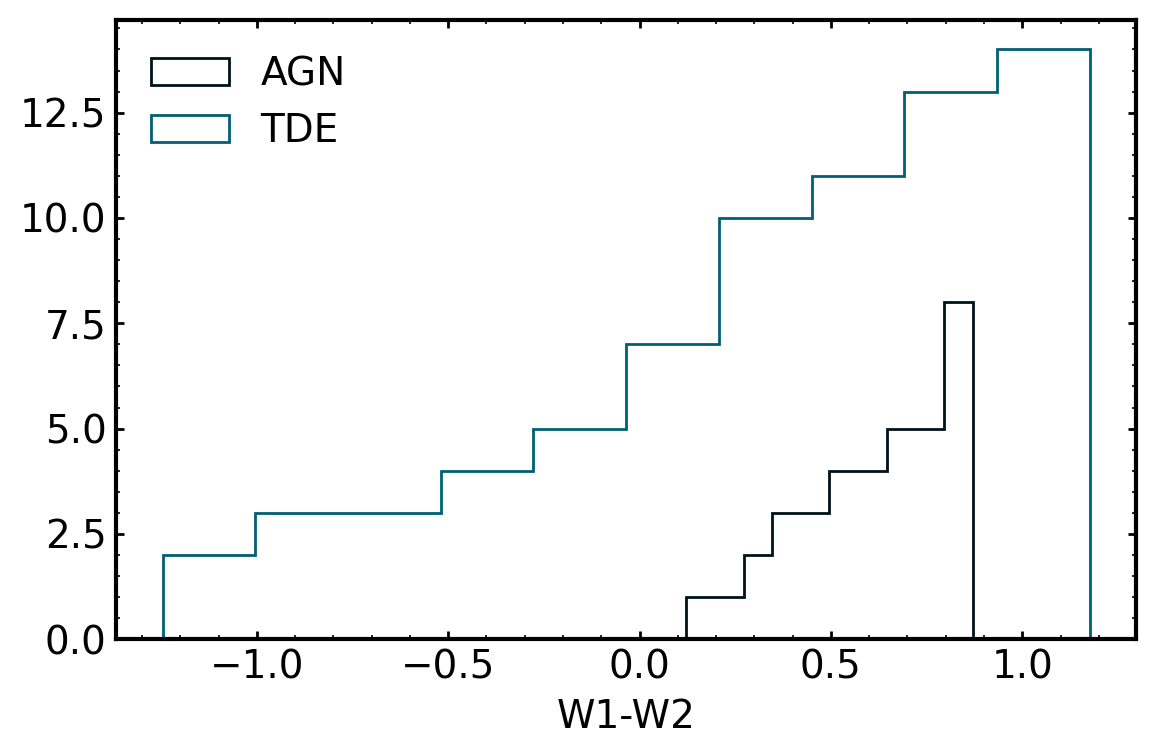

In [10]:
fig, ax = plt.subplots(1,1, figsize=(6,4))

agn = dust_echo_df[dust_echo_df['class'] == 'AGN']
tde = dust_echo_df[dust_echo_df['class'] == 'TDE']

ax.hist(agn.w1_lum-agn.w2_lum, histtype='step', cumulative=True, label='AGN')
ax.hist(tde.w1_lum-tde.w2_lum, histtype='step', cumulative=True, label='TDE')
ax.legend()
# ax2.hist(agn.w2_mean_lum, histtype='step', cumulative=True)
# ax2.hist(tde.w2_mean_lum, histtype='step', cumulative=True)

ax.set_xlabel('W1-W2')

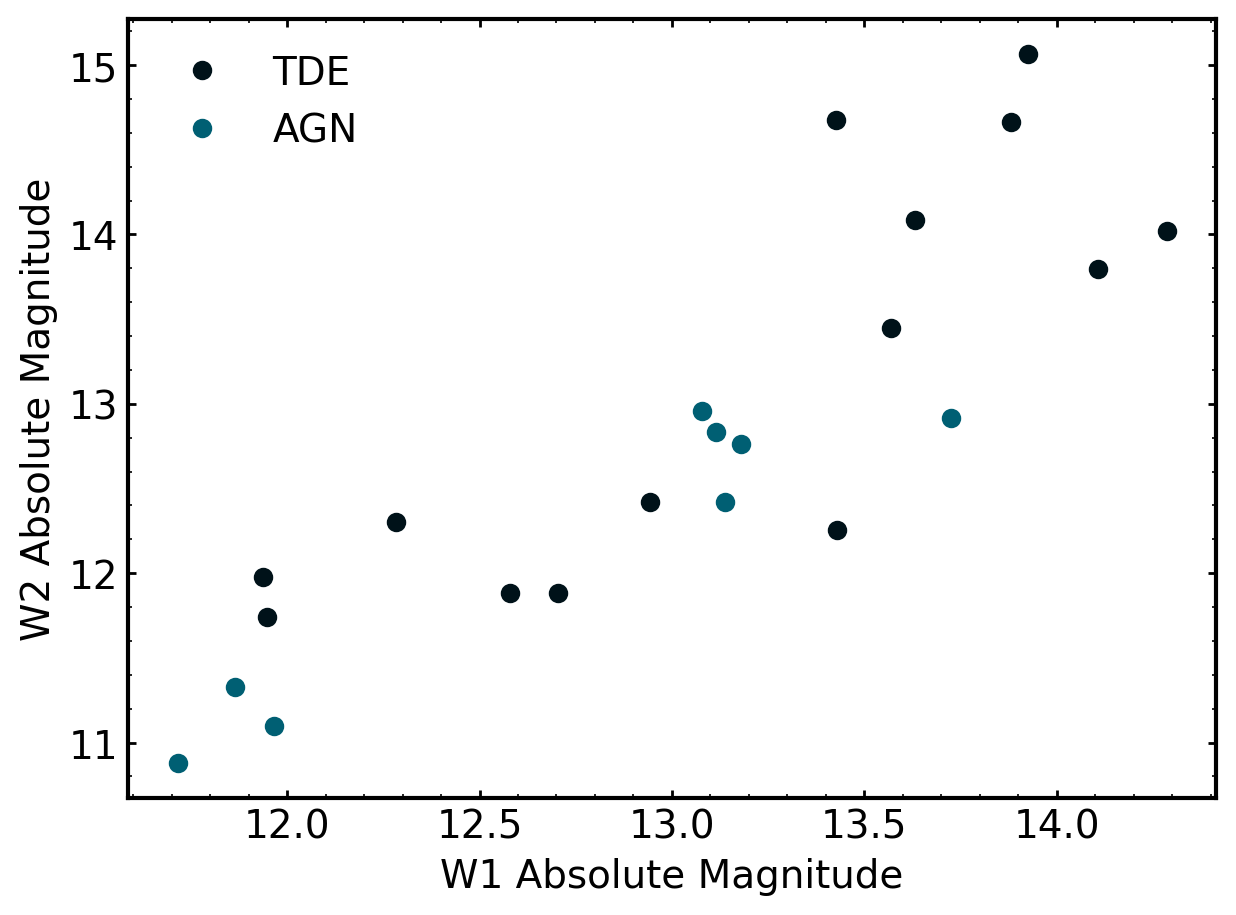

In [11]:
fig,ax = plt.subplots()

ax.plot(tde.w1_lum, tde.w2_lum, label='TDE', marker='o', linestyle='none')
ax.plot(agn.w1_lum, agn.w2_lum, label='AGN', marker='o', linestyle='none')

ax.set_xlabel('W1 Absolute Magnitude')
ax.set_ylabel('W2 Absolute Magnitude')

ax.legend()

In [12]:
res_w1 = kstest(tde.w1_lum, agn.w1_lum)
res_w2 = kstest(tde.w2_lum, agn.w2_lum)
res_w2_minus_w1 = kstest(tde.w1_lum-tde.w2_lum, agn.w1_lum-agn.w2_lum)

print(f'W1 p-value   : {res_w1.pvalue}\nW2 p-value   : {res_w2.pvalue}\nW1-W2 p-value: {res_w2_minus_w1.pvalue}')

W1 p-value   : 0.19273227632360757
W2 p-value   : 0.11510773368358511
W1-W2 p-value: 0.0909841448541139


# Compare Radio and IR properties

In [13]:
radio_class = []
for name, wise_data in dust_echo_df.groupby('name'):
    radio_phot = db.get_phot(names=name, obs_type='radio', return_type='pandas')
    radio_phot = radio_phot[radio_phot.converted_date > wise_data.discovery_date.values[0]] # we only care about detections after discovery
    is_radio_bright = np.any(radio_phot.upperlimit == False)
    radio_class.append(is_radio_bright)
    
dust_echo_df['is_radio_bright'] = radio_class

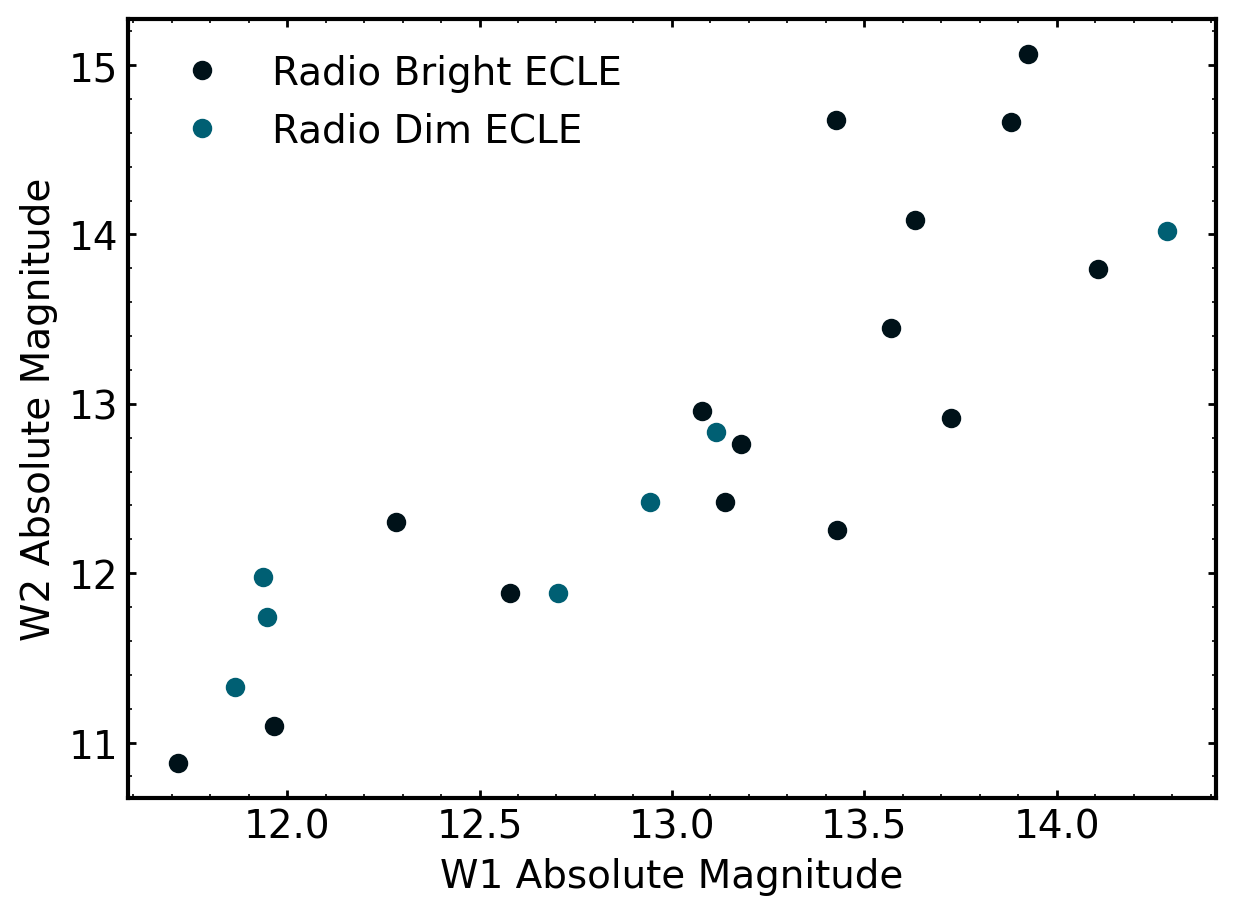

In [14]:
radio_bright = dust_echo_df[dust_echo_df.is_radio_bright]
radio_dim = dust_echo_df[~dust_echo_df.is_radio_bright]

fig,ax = plt.subplots()

ax.plot(radio_bright.w1_lum, radio_bright.w2_lum, label='Radio Bright ECLE', marker='o', linestyle='none')
ax.plot(radio_dim.w1_lum, radio_dim.w2_lum, label='Radio Dim ECLE', marker='o', linestyle='none')

ax.set_xlabel('W1 Absolute Magnitude')
ax.set_ylabel('W2 Absolute Magnitude')

ax.legend()

In [15]:
# All ECLEs
res_w1 = kstest(radio_bright.w1_lum, radio_dim.w1_lum)
res_w2 = kstest(radio_bright.w2_lum, radio_dim.w2_lum)

print(f'W1 p-value: {res_w1.pvalue}\nW2 p-value: {res_w2.pvalue}')

W1 p-value: 0.10075992119335772
W2 p-value: 0.3553100666103762


In [16]:
# Just the TDEs

bright_tdes = radio_bright[radio_bright['class'] == 'TDE']
dim_tdes = radio_dim[radio_dim['class'] == 'TDE']

res_w1 = kstest(bright_tdes.w1_lum, dim_tdes.w1_lum)
res_w2 = kstest(bright_tdes.w2_lum, dim_tdes.w2_lum)

print(f'W1 p-value: {res_w1.pvalue}\nW2 p-value: {res_w2.pvalue}')

W1 p-value: 0.17282717282717286
W2 p-value: 0.30069930069930073


Text(0.5, 0, 'Number of ECLEs')

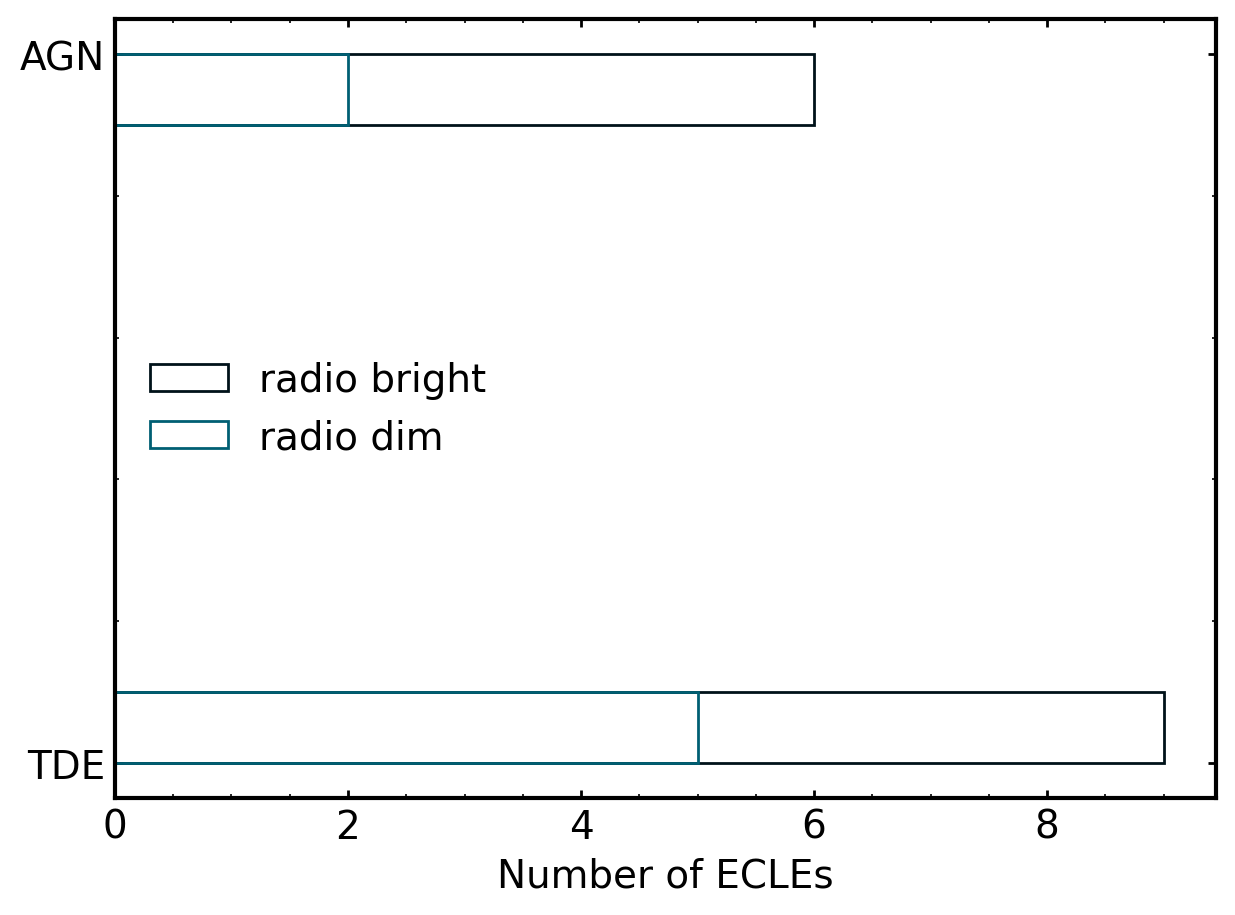

In [17]:
fig,ax = plt.subplots()
ax.hist(radio_bright['class'], label='radio bright', histtype='step', orientation='horizontal')
ax.hist(radio_dim['class'], label='radio dim', histtype='step', orientation='horizontal')

ax.legend(loc='center left')

ax.set_xlabel('Number of ECLEs')

In [18]:
res = kstest(radio_bright['class'], radio_dim['class'])

res.pvalue

0.9999882728210903

In [19]:
dust_echo_df

,name,w1_flux,w1_lum,w2_flux,w2_lum,class,discovery_date,is_radio_bright
0,2019qiz,5.322820e-11,11.948066,4.769390e-11,11.739066,TDE,58750.410000,False
1,AT2017gge,7.293597e-12,14.106066,7.165770e-12,13.797066,TDE,57968.349988,True
2,AT2018bcb,2.974006e-11,12.580066,4.184686e-11,11.881066,TDE,58235.120000,True
3,AT2018dyk,5.372072e-11,11.938066,3.837628e-11,11.975066,TDE,58269.310000,False
4,AT2021acak,2.128834e-11,12.943066,2.547199e-11,12.420066,TDE,59509.620000,False
5,AT2021dms,3.909685e-11,12.283066,2.842254e-11,12.301066,TDE,59266.145706,True
6,AT2022fpx,6.185030e-12,14.285066,5.829924e-12,14.021066,TDE,59669.519810,False
7,AT2022upj,1.194928e-11,13.570066,9.873312e-12,13.449066,TDE,59822.378000,True
8,SDSS_J0748,1.363144e-11,13.427066,3.197885e-12,14.673066,TDE,53055.000000,True
9,SDSS_J0807,6.590855e-11,11.716066,1.051146e-10,10.881066,AGN,53682.000000,True


In [20]:
def compute_decision_boundary(X, clf, ax=None, n=1000, idxs_to_plot=(0,1)):
    
    ndim = X.shape[1] # this is the number of dimensions accepted by the clf
    
    invals = np.array([np.linspace(X[:,i].min()-0.5, X[:,i].max()+0.5, n) for i in range(ndim)])
    
    if ax is None:
        _, ax = plt.subplots()
        
    x, y = np.meshgrid(
        invals[idxs_to_plot[0]],
        invals[idxs_to_plot[1]]
    )
    
    predicted = np.array([clf.predict(np.array(v).T) for v in zip(x,y,list(invals[2:])*len(x))])    
    c = ax.contourf(x, y, predicted, cmap='bone_r')
    return c

/tmp/ipykernel_3968832/2222111540.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['is_radio_bright'] = data.is_radio_bright.astype(int)


[Text(1, 0, 'TDE'), Text(1, 1, 'AGN')]

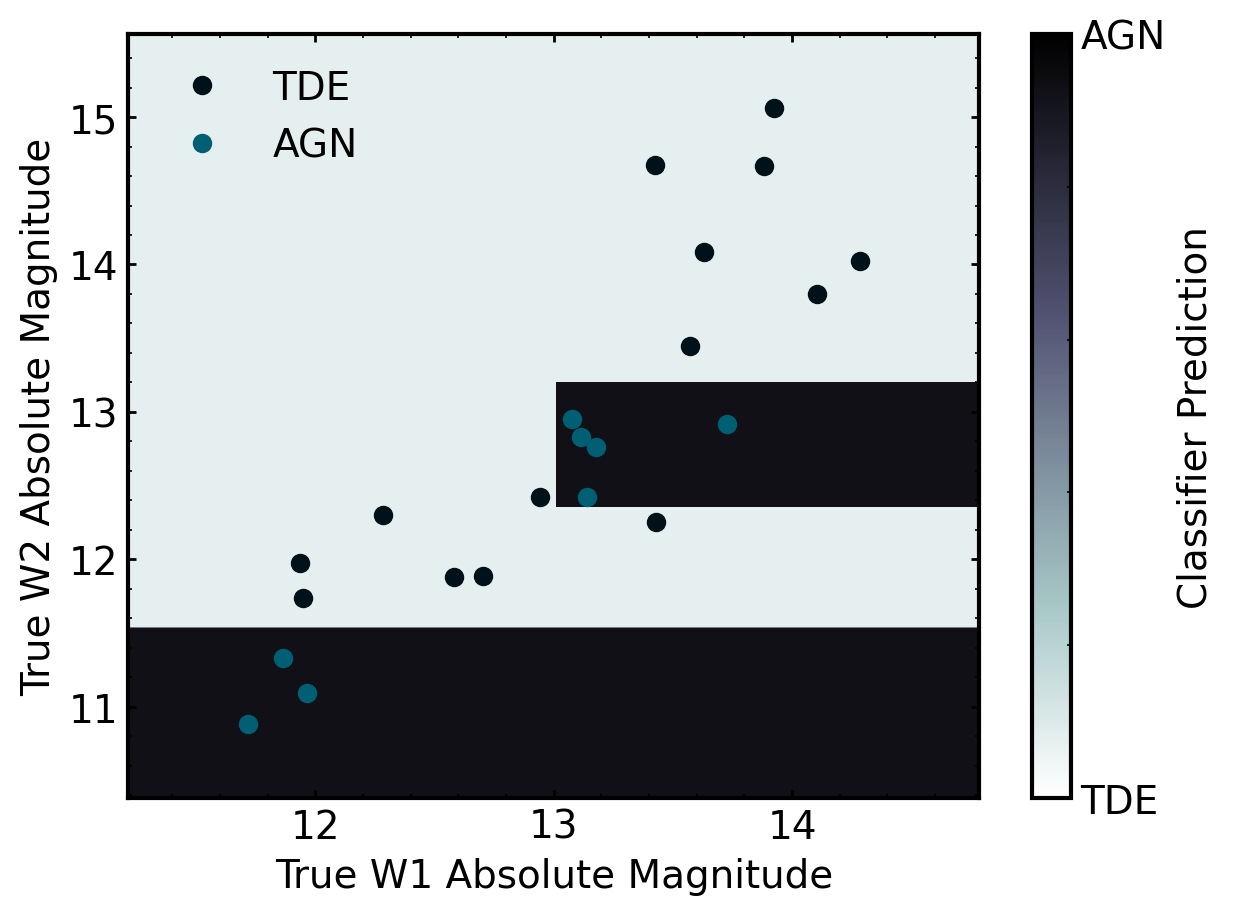

In [21]:
# see what cut a classifier gives this data

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree

label_map = {'TDE': 0, 'AGN': 1}

keys_to_keep = ['w1_lum', 'w2_lum', 'is_radio_bright']
plot_keys = keys_to_keep[:2]

data = dust_echo_df[keys_to_keep]
data['is_radio_bright'] = data.is_radio_bright.astype(int)
targ = dust_echo_df['class'].replace(label_map)

clf = DecisionTreeClassifier()
clf.fit(data, targ)

# plot_tree(clf);

fig,ax = plt.subplots()

ax.plot(tde.w1_lum, tde.w2_lum, label='TDE', marker='o', linestyle='none')
ax.plot(agn.w1_lum, agn.w2_lum, label='AGN', marker='o', linestyle='none')

c = compute_decision_boundary(data.values, clf, ax=ax)

ax.set_xlabel('True W1 Absolute Magnitude')
ax.set_ylabel('True W2 Absolute Magnitude')

ax.legend()


from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
cmappable = ScalarMappable(norm=Normalize(0,1), cmap=c.cmap)
cbar = fig.colorbar(cmappable, ax=ax, ticks=[0,1], label='Classifier Prediction')
cbar.ax.set_yticklabels(['TDE', 'AGN']) 